# Technical Note P13: Matplotlib, pandas, and Verification Workflow

**Wook Kang · Revised English edition · Version 1.0.0 · 3 October 2026**

This note connects a mathematical task to a numerical object, an implementation, and evidence about the result. It is an instructional computational document. Demonstration parameters are illustrative unless explicitly stated otherwise.

Run from a fresh kernel in cell order. See [the series README](../README.md) for setup and [editorial and verification notes](../docs/EDITORIAL_NOTES.md) for scope and limitations. The English prose has been reorganized and expanded from the supplied Korean notebook; this is an adapted edition rather than a line-by-line translation.

**Reading question:** What is given, what is unknown, what operation relates them, and what independent check can assess the output?

## Core mathematical structure

$$
\boxed{
\text{compute}
\rightarrow
\text{inspect}
\rightarrow
\text{verify}
\rightarrow
\text{record}
}
$$

In [1]:
# Reproducible display and scale-aware comparison.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
def scaled_allclose(a, b, rtol=1e-12, atol=None, **kwargs):
    """Compare numerical examples using an absolute tolerance scaled to b."""
    a, b = np.asarray(a), np.asarray(b)
    scale = float(np.max(np.abs(b))) if b.size else 0.0
    if atol is None:
        atol = 1e-14 * max(scale, np.finfo(float).tiny)
    return np.allclose(a, b, rtol=rtol, atol=atol, **kwargs)


## 1. Plots diagnose calculations

Use plots to check orientation, sign, boundary behaviour, oscillations, residuals, and convergence. Presentation quality is secondary to a faithful representation of the data.

$$
\boxed{
\text{plotting}=
\text{visual verification}
}
$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sys
import platform
from pathlib import Path

## 2. One-dimensional solutions

Start with a labelled curve and its coordinate values. State whether axes use physical units or nondimensional demonstration values.

$$
u(x)=\sin(\pi x)
$$

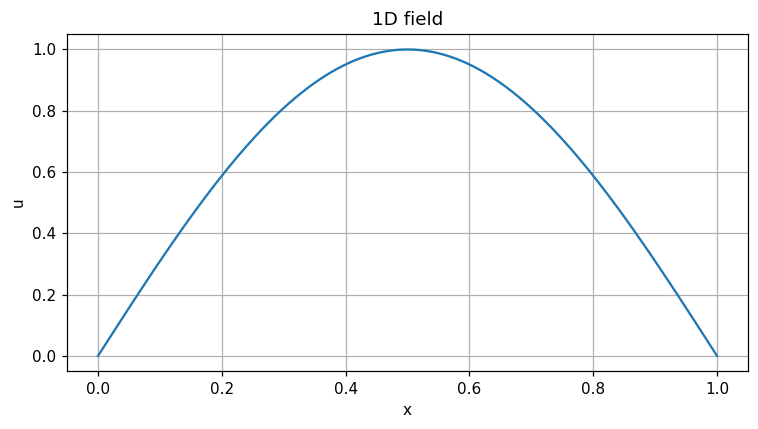

In [3]:
x = np.linspace(0, 1, 200)
u = np.sin(np.pi*x)

plt.figure(figsize=(7, 4))
plt.plot(x, u)
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D field")
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Compare exact and numerical solutions

Evaluate both at identical locations and times. A visual overlap should be supplemented by a numerical error measure.

$$
\boxed{
\text{numerical}
\quad\text{vs}\quad
\text{reference / exact}
}
$$

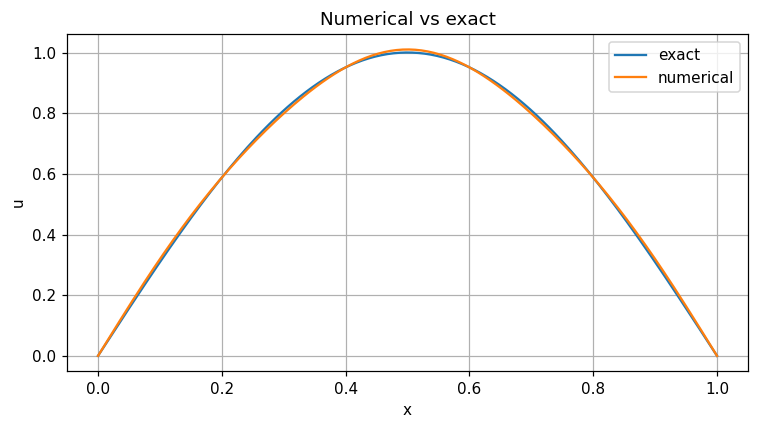

In [4]:
u_exact = np.sin(np.pi*x)
u_num = u_exact + 0.01*np.sin(5*np.pi*x)

plt.figure(figsize=(7, 4))
plt.plot(x, u_exact, label="exact")
plt.plot(x, u_num, label="numerical")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Numerical vs exact")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Plot the error separately

Plot the difference and report its norm or maximum. Two nearly overlapping curves can still hide a consequential error at a small scale.

$$
e(x)=u_{\mathrm{num}}-u_{\mathrm{ref}}
$$

L_inf error = 0.009999688468941559
RMS error = 0.0070533679898329375


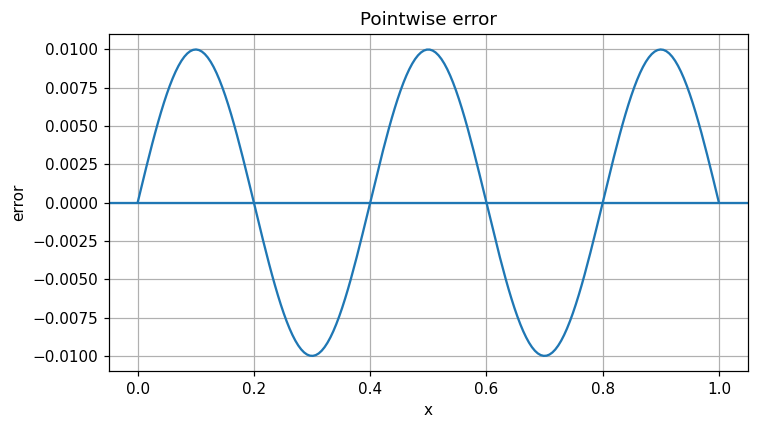

In [5]:
error = u_num - u_exact

plt.figure(figsize=(7, 4))
plt.plot(x, error)
plt.axhline(0.0)
plt.xlabel("x")
plt.ylabel("error")
plt.title("Pointwise error")
plt.grid(True)
plt.tight_layout()
plt.show()

print("L_inf error =", np.max(np.abs(error)))
print("RMS error =", np.sqrt(np.mean(error**2)))

## 5. Residual and error

Residual measures satisfaction of an equation; error compares with a true or reference solution. A small residual implies a small error only with suitable stability and conditioning information.

$$
e=u_{\mathrm{num}}-u_{\mathrm{true}}
$$

$$
r=Au-b
$$

$$
\boxed{
\text{small residual}
\neq
\text{small solution error}
}
$$

## 6. Residual patterns

Plot individual residuals in their observation order. Trends and changing spread can indicate model discrepancy, boundary mismatch, or an unsuitable noise model.

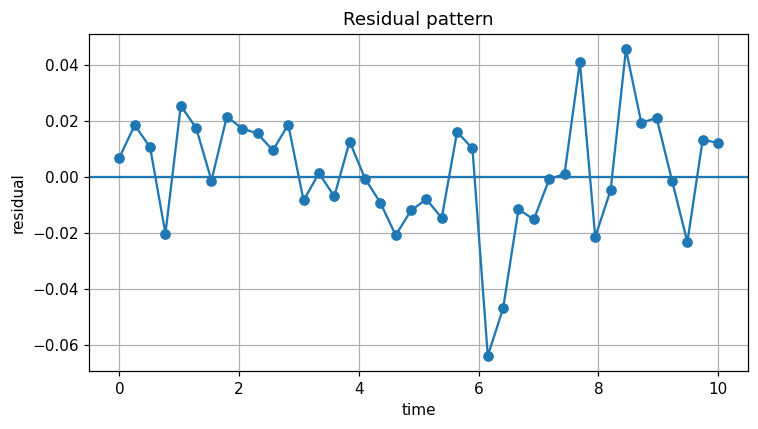

In [6]:
t = np.linspace(0, 10, 40)
rng = np.random.default_rng(1)

residual = 0.02*rng.normal(size=t.size) + 0.01*np.sin(0.8*t)

plt.figure(figsize=(7, 4))
plt.axhline(0.0)
plt.plot(t, residual, marker="o")
plt.xlabel("time")
plt.ylabel("residual")
plt.title("Residual pattern")
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Convergence plots

Measured refinement errors support an observed order. The e=h-squared plot here is an illustrative reference curve, not a measured convergence experiment.

$$
E(h)\propto h^p
$$

estimated order = 2.0000000000000004


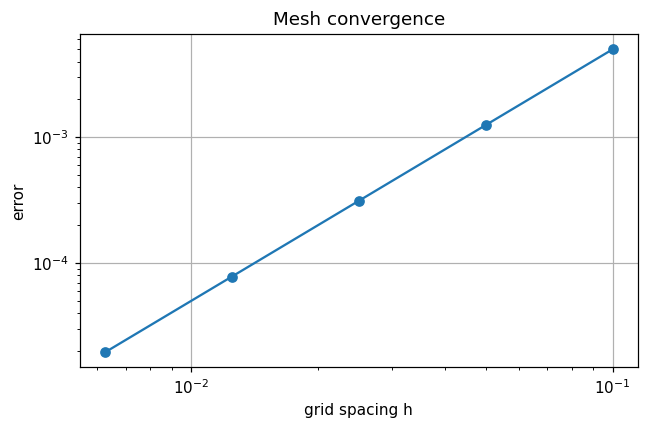

In [7]:
h = np.array([1/10, 1/20, 1/40, 1/80, 1/160])
error = 0.5*h**2

plt.figure(figsize=(6, 4))
plt.loglog(h, error, marker="o")
plt.xlabel("grid spacing h")
plt.ylabel("error")
plt.title("Mesh convergence")
plt.grid(True)
plt.tight_layout()
plt.show()

p = np.polyfit(np.log(h), np.log(error), 1)[0]
print("estimated order =", p)

## 8. Time-step refinement

Change time discretization while holding other error sources sufficiently controlled. A synthetic power-law reference illustrates plotting rather than verifying a solver.

$$
\Delta t,\quad
\Delta t/2,\quad
\Delta t/4
$$

estimated temporal order = 0.9999999999999999


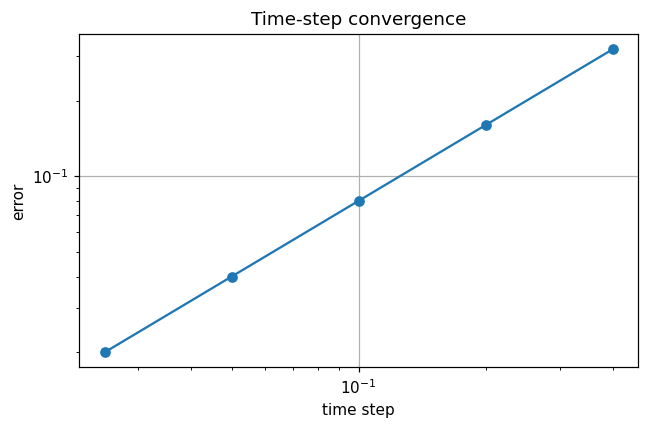

In [8]:
dt = np.array([0.4, 0.2, 0.1, 0.05, 0.025])
err_t = 0.8*dt

plt.figure(figsize=(6, 4))
plt.loglog(dt, err_t, marker="o")
plt.xlabel("time step")
plt.ylabel("error")
plt.title("Time-step convergence")
plt.grid(True)
plt.tight_layout()
plt.show()

p_t = np.polyfit(np.log(dt), np.log(err_t), 1)[0]
print("estimated temporal order =", p_t)

## 9. Scalar-field plots

Imshow uses rows and columns; x-first field storage often requires transpose. State extent and origin and check coordinates with an asymmetric reference field.

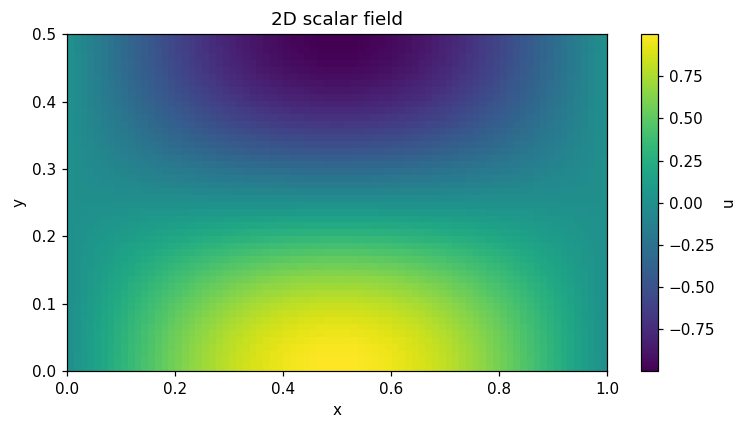

In [9]:
x2 = np.linspace(0, 1, 80)
y2 = np.linspace(0, 0.5, 50)
X2, Y2 = np.meshgrid(x2, y2, indexing="ij")
U2 = np.sin(np.pi*X2)*np.cos(2*np.pi*Y2)

plt.figure(figsize=(7, 4))
plt.imshow(
    U2.T,
    origin="lower",
    aspect="auto",
    extent=[x2.min(), x2.max(), y2.min(), y2.max()]
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D scalar field")
plt.colorbar(label="u")
plt.tight_layout()
plt.show()

## 10. Vector-field plots

Quiver displays vector direction and scale. Use consistent coordinates and component conventions, and disclose arrow rescaling when it matters.

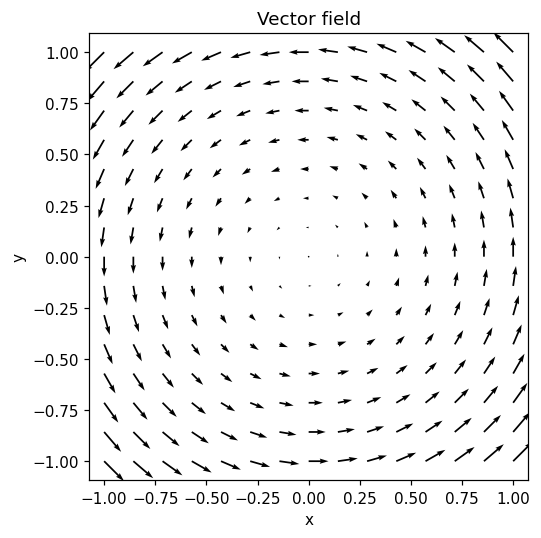

In [10]:
xq = np.linspace(-1, 1, 15)
yq = np.linspace(-1, 1, 15)
Xq, Yq = np.meshgrid(xq, yq, indexing="ij")

Vx = -Yq
Vy = Xq

plt.figure(figsize=(5, 5))
plt.quiver(Xq, Yq, Vx, Vy)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Vector field")
plt.axis("equal")
plt.tight_layout()
plt.show()

## 11. Units and scales

Axis labels are a dimensional check. Mixing seconds and hours or moisture fractions and percentages can invalidate a model while leaving the graph plausible.

$$
\boxed{
\text{unit label}=
\text{verification aid}
}
$$

## 12. Tabular records

Pandas stores observations, settings, and summaries with semantic column labels. It does not replace the numerical solver or enforce a physical schema automatically.

$$
\boxed{
\text{NumPy}=
\text{numerical arrays}
}
$$

$$
\boxed{
\text{pandas}=
\text{labeled tables}
}
$$

In [11]:
df = pd.DataFrame({
    "time_h": [0, 1, 2, 4, 8],
    "moisture": [0.30, 0.27, 0.24, 0.20, 0.16],
})

print(df)

   time_h  moisture
0       0      0.30
1       1      0.27
2       2      0.24
3       4      0.20
4       8      0.16


## 13. Columns carry meaning

Use names that expose quantity and units. A dtype should agree with whether the column represents a number, category, identifier, or timestamp.

```python
df["time_h"]
df["moisture"]
```

In [12]:
print(df["time_h"].to_numpy())
print(df["moisture"].to_numpy())

[0 1 2 4 8]
[0.3  0.27 0.24 0.2  0.16]


## 14. CSV round trips

Write and read a table, then check values and schema. Revised examples use an outputs directory relative to the working location rather than a fixed system path.

In [13]:
csv_path = OUTPUT_DIR / "p13_example_data.csv"

df.to_csv(csv_path, index=False)
df2 = pd.read_csv(csv_path)

print(df2)

   time_h  moisture
0       0      0.30
1       1      0.27
2       2      0.24
3       4      0.20
4       8      0.16


## 15. Validate imported data

Check required columns, finite values, monotone coordinates, duplicates, units, and plausible ranges. Reject invalid inputs explicitly when the checks are required for execution.

In [14]:
required = {"time_h", "moisture"}

print("required columns present?", required.issubset(df2.columns))
print("any NaN?", df2.isna().any().any())
print("time monotonic?", df2["time_h"].is_monotonic_increasing)
print("duplicate time?", df2["time_h"].duplicated().any())
print("moisture nonnegative?", (df2["moisture"] >= 0).all())

required columns present? True
any NaN? False
time monotonic? True
duplicate time? False
moisture nonnegative? True


## 16. Explicit unit conversion

Record conversions such as hours to seconds at a visible interface. Include the original and internal unit convention in the experiment record.

$$
t_{\mathrm{s}}=
3600\,t_{\mathrm{h}}
$$

In [15]:
df2["time_s"] = 3600.0*df2["time_h"]

print(df2)

   time_h  moisture   time_s
0       0      0.30      0.0
1       1      0.27   3600.0
2       2      0.24   7200.0
3       4      0.20  14400.0
4       8      0.16  28800.0


$$
\boxed{
\text{correct formula}
+
\text{wrong units}=
\text{wrong model result}
}
$$

## 17. Parameter tables

Record parameter values together with their units and provenance. A parameter value without a definition of state and measurement basis is incomplete.

In [16]:
params = pd.DataFrame({
    "parameter": ["D", "h", "L", "u0", "u_inf"],
    "value": [1e-10, 2e-8, 0.02, 0.30, 0.10],
    "unit": ["m^2/s", "m/s", "m", "-", "-"],
})

print(params)

  parameter         value   unit
0         D  1.000000e-10  m^2/s
1         h  2.000000e-08    m/s
2         L  2.000000e-02      m
3        u0  3.000000e-01      -
4     u_inf  1.000000e-01      -


## 18. Result summaries

Summaries should name the metric, dataset, and calculation configuration. Separate calibration metrics from independent prediction metrics.

In [17]:
results = pd.DataFrame({
    "metric": ["RMSE", "NRMSE", "R2", "iterations"],
    "value": [0.0042, 0.021, 0.995, 7],
})

print(results)

       metric   value
0        RMSE  0.0042
1       NRMSE  0.0210
2          R2  0.9950
3  iterations  7.0000


## 19. Long-format observations

Store sample or experiment identifiers beside time and measured response. This facilitates grouping while preserving which observations belong together.

In [18]:
df_multi = pd.DataFrame({
    "experiment": ["A","A","A","B","B","B"],
    "time_h": [0,1,2,0,1,2],
    "moisture": [0.30,0.27,0.24,0.30,0.26,0.22],
})

print(df_multi)
print()
print(df_multi.groupby("experiment")["moisture"].mean())

  experiment  time_h  moisture
0          A       0      0.30
1          A       1      0.27
2          A       2      0.24
3          B       0      0.30
4          B       1      0.26
5          B       2      0.22

experiment
A    0.27
B    0.26
Name: moisture, dtype: float64


## 20. Plot from a DataFrame

Named columns make a plotting call more legible. Verify sorting and units before connecting observations with a line.

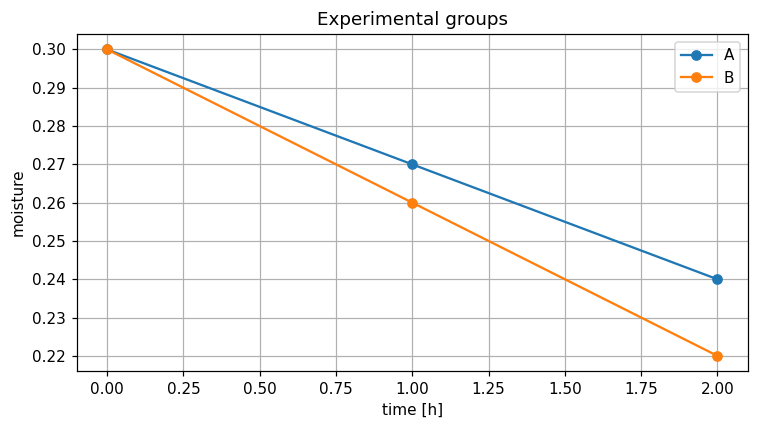

In [19]:
plt.figure(figsize=(7, 4))

for name, group in df_multi.groupby("experiment"):
    plt.plot(
        group["time_h"],
        group["moisture"],
        marker="o",
        label=name,
    )

plt.xlabel("time [h]")
plt.ylabel("moisture")
plt.title("Experimental groups")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 21. Layers of assessment

Distinguish implementation checks, numerical verification, physical validation, and parameter identifiability. Passing one layer does not automatically pass the others.

$$
\boxed{
\begin{array}{l}
\text{code correctness}\\
\text{numerical verification}\\
\text{model validation}\\
\text{parameter identifiability}
\end{array}
}
$$

## 22. Implementation correctness

Check indexing, signs, units, boundary placement, ordering, and aliasing. Small independent examples can expose mistakes that large runs conceal.

## 23. Numerical verification

Use refinement, residuals, conservation, and independent references to assess whether the discrete calculation represents the intended equations accurately.

## 24. Physical validation

Compare with independent measurements at relevant conditions. A mathematically accurate solve can still use an inadequate model or unmeasured inputs.

## 25. Identifiability

Assess whether the available data distinguish parameter effects. A converged optimizer can leave broad parameter tradeoffs unresolved.

$$
\boxed{
\text{model fit}
\neq
\text{parameter uniqueness}
}
$$

## 26. Conservation

Derive the conserved total from the model and boundary conditions. The original demonstration intentionally violates its claimed total so that the diagnostic visibly detects the discrepancy.

In [20]:
C1, C2 = 1.0, 2.0
T1 = np.array([100.0, 80.0, 70.0])
T2 = np.array([20.0, 30.0, 35.0])

E = C1*T1 + C2*T2

print("energy values =", E)
print("energy variation =", E.max()-E.min())

energy values = [140. 140. 140.]
energy variation = 0.0


## 27. Manufactured solutions

Choose a smooth reference, substitute it into the operator, and derive the necessary source and boundary data. This tests the implemented operator under controlled conditions.

$$
\boxed{
\text{known solution}
\rightarrow
\text{derived source}
\rightarrow
\text{solver verification}
}
$$

## 28. A manufactured ODE

The specified sine solution gives a cosine rate with a matching initial value. Compare the numerical trajectory against the chosen reference and an explicit tolerance.

$$
y(t)=\sin t
$$

$$
\dot y=\cos t
$$

In [21]:
from scipy.integrate import solve_ivp

def rhs_mms(t, y):
    return [np.cos(t)]

t_eval = np.linspace(0, 2*np.pi, 101)

sol = solve_ivp(
    rhs_mms,
    (0, 2*np.pi),
    [0.0],
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-12,
)

err = sol.y[0] - np.sin(sol.t)

print("max MMS error =", np.max(np.abs(err)))

max MMS error = 5.411168069180405e-09


## 29. Cross-method checks

Agreement between methods is useful when they have independent formulations. Shared assumptions or shared implementation mistakes can still produce agreement.

$$
\boxed{
\text{independent implementation}
\rightarrow
\text{stronger verification}
}
$$

## 30. Record residual norms

Report absolute and scaled residuals with the norm definition. Handle a zero scaling denominator explicitly.

In [22]:
A = np.array([
    [3.0, 1.0],
    [1.0, 2.0],
])
b = np.array([9.0, 8.0])

xsol = np.linalg.solve(A, b)
r = A @ xsol - b

summary = {
    "abs_residual_norm": np.linalg.norm(r),
    "rel_residual_norm": np.linalg.norm(r)/np.linalg.norm(b),
}

print(summary)

{'abs_residual_norm': np.float64(0.0), 'rel_residual_norm': np.float64(0.0)}


## 31. Assertions for internal checks

Use assertions for development invariants and explicit exceptions for required runtime validation. Python can disable asserts under optimization.

In [23]:
assert np.all(np.isfinite(xsol))
assert np.linalg.norm(r) < 1e-10

print("basic assertions passed")

basic assertions passed


## 32. Shape contracts

Check expected shapes at interfaces. A correct shape does not establish correct axis meaning, so also document the convention.

In [24]:
U = np.zeros((20, 30))
assert U.ndim == 2
assert U.shape == (20, 30)

print("shape assertions passed")

shape assertions passed


## 33. Positivity and bounds

Check coefficients and states against model requirements. Automatic clipping can hide a failed calculation and alter conservation.

In [25]:
D = np.array([1e-10, 2e-10, 3e-10])

assert np.all(D > 0)

print("positivity check passed")

positivity check passed


## 34. Reusable verification functions

Make checks report a named condition, observed quantity, tolerance, and outcome. A boolean without this context is difficult to audit.

In [26]:
def check_field(U, name="field", require_nonnegative=False):
    U = np.asarray(U)

    report = {
        "name": name,
        "shape": U.shape,
        "finite": bool(np.all(np.isfinite(U))),
        "min": float(np.nanmin(U)),
        "max": float(np.nanmax(U)),
        "mean": float(np.nanmean(U)),
    }

    if require_nonnegative:
        report["nonnegative"] = bool(np.all(U >= 0))

    return report

print(check_field(np.linspace(0, 1, 10), "moisture", True))

{'name': 'moisture', 'shape': (10,), 'finite': True, 'min': 0.0, 'max': 1.0, 'mean': 0.5, 'nonnegative': True}


## 35. Verification tables

Record both successful and failed checks. Do not relabel a deliberately failed pedagogical example as a solver failure or silently discard it.

In [27]:
reports = [
    check_field(np.linspace(0,1,10), "u"),
    check_field(np.linspace(1,2,10), "D", True),
]

verification_df = pd.DataFrame(reports)

print(verification_df)

  name  shape  finite  min  max  mean nonnegative
0    u  (10,)    True  0.0  1.0   0.5         NaN
1    D  (10,)    True  1.0  2.0   1.5        True


## 36. Random seeds

Use an explicit random generator and record its seed. Reproducibility also depends on algorithms, package versions, hardware, and parallel execution.

In [28]:
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(1234)

a = rng1.normal(size=5)
b = rng2.normal(size=5)

print(a)
print(b)
print("same?", scaled_allclose(a, b))

[-1.60383681  0.06409991  0.7408913   0.15261919  0.86374389]
[-1.60383681  0.06409991  0.7408913   0.15261919  0.86374389]
same? True


## 37. Environment records

Record Python and library versions and relevant platform information. Distinguish the tested environment from an untested claimed compatibility range.

In [29]:
env = pd.DataFrame({
    "item": [
        "Python",
        "NumPy",
        "SciPy",
        "pandas",
        "Matplotlib",
        "Platform",
    ],
    "version": [
        sys.version.split()[0],
        np.__version__,
        scipy.__version__,
        pd.__version__,
        plt.matplotlib.__version__,
        platform.platform(),
    ],
})

print(env)

         item                              version
0      Python                              3.12.14
1       NumPy                                2.3.5
2       SciPy                               1.17.0
3      pandas                                2.2.3
4  Matplotlib                               3.10.8
5    Platform  Linux-6.18.44-x86_64-with-glibc2.39


## 38. Save the environment

Write a machine-readable environment table beside numerical outputs. Keep the path relative and create the output directory explicitly.

In [30]:
env_path = OUTPUT_DIR / "p13_environment.csv"
env.to_csv(env_path, index=False)

print("saved:", env_path)

saved: outputs/p13_environment.csv


## 39. Separate inputs, configuration, and results

Preserve observation data, model and solver choices, and generated results as different records. This supports reruns and meaningful comparisons.

$$
\boxed{
\text{input data}
}
$$

$$
\boxed{
\text{configuration}
}
$$

$$
\boxed{
\text{results}
}
$$

```text
data/
config/
results/
figures/
notebooks/
```

## 40. A minimal experiment record

Include a run identifier, model version, parameters, discretization, tolerances, solver, metrics, and environment. Add data provenance and units where applicable.

In [31]:
run_record = pd.DataFrame([{
    "run_id": "demo_001",
    "model": "diffusion_demo",
    "Nx": 40,
    "dt": 1800.0,
    "solver": "BDF",
    "rtol": 1e-6,
    "rmse": 0.0042,
}])

print(run_record)

     run_id           model  Nx      dt solver      rtol    rmse
0  demo_001  diffusion_demo  40  1800.0    BDF  0.000001  0.0042


## 41. Save figures

Save with explicit dimensions or resolution and bounding-box choices. The revised example labels its synthetic convergence curve as an illustration.

```python
plt.savefig(...)
```

saved: outputs/p13_example_convergence.png


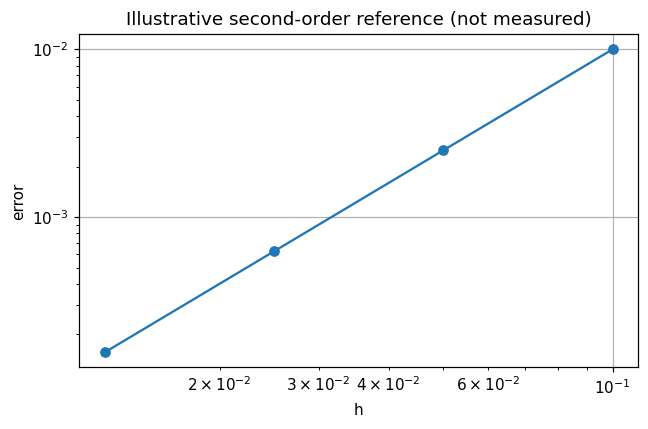

In [32]:
fig_path = OUTPUT_DIR / "p13_example_convergence.png"

h = np.array([1/10, 1/20, 1/40, 1/80])
e = h**2

plt.figure(figsize=(6,4))
plt.loglog(h, e, marker="o")
plt.xlabel("h")
plt.ylabel("error")
plt.title("Illustrative second-order reference (not measured)")
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", fig_path)

## 42. Visualization failure modes

Wrong axis order, missing units, misleading limits, log-scale exclusions, and interpolated detail can distort interpretation. Inspect the plotted data as well as the figure.

$$
\boxed{
\text{beautiful plot}
\neq
\text{correct plot}
}
$$

## 43. DataFrame failure modes

Object dtypes, missing values, duplicates, label alignment, and inconsistent sorting can change a calculation. Validate tables before converting to numerical arrays.

In [33]:
df_bad = pd.DataFrame({
    "x": [1, 2, 3],
    "y": ["1.0", "2.0", "bad"],
})

print(df_bad.dtypes)

numeric_y = pd.to_numeric(df_bad["y"], errors="coerce")

print(numeric_y)
print("NaN created?", numeric_y.isna().any())

x     int64
y    object
dtype: object
0    1.0
1    2.0
2    NaN
Name: y, dtype: float64
NaN created? True


## 44. Index alignment

Pandas arithmetic aligns labels rather than blindly matching positions. Convert or reindex deliberately when positional arithmetic is intended.

In [34]:
s1 = pd.Series([1,2,3], index=["a","b","c"])
s2 = pd.Series([10,20,30], index=["b","c","d"])

print(s1 + s2)

a     NaN
b    12.0
c    23.0
d     NaN
dtype: float64


$$
\boxed{
\text{pandas arithmetic}
=
\text{label-aware}
}
$$

## 45. Verification checklist

Check units, axis conventions, boundaries, finite values, admissibility, residuals, conservation, spatial and time refinement, and an independent reference where available.

## 46. Verification and validation

Verification asks whether the intended equations are solved adequately. Validation asks whether those equations predict relevant observations adequately within a stated domain.

$$
\boxed{
\text{verification}
\neq
\text{validation}
}
$$

## 47. Fit and prediction

A calibration fit uses the data that determined parameters. Predictive assessment requires observations or conditions not already used to tune the model.

## 48. The complete workflow

Formulate the question, define objects and units, construct a discretization, solve, inspect, verify, validate when data permit, and preserve an interpretable record.

$$
\boxed{
\begin{array}{c}
\text{Define mathematical problem}\\
\downarrow\\
\text{Choose numerical representation}\\
\downarrow\\
\text{Choose algorithm}\\
\downarrow\\
\text{Compute}\\
\downarrow\\
\text{Inspect}\\
\downarrow\\
\text{Verify}\\
\downarrow\\
\text{Validate}\\
\downarrow\\
\text{Record}
\end{array}
}
$$

## 49. The series map

P0-P6 develop language and numerical objects; P7-P12 develop algorithms; P13 connects the calculation to evidence and reproducibility.

| TN | Main topic |  
| --- | --- |  
| P0 | Scientific Python Ecosystem Map |  
| P1 | Python Computational Grammar |  
| P2 | NumPy Array, Shape, Axis |  
| P3 | Indexing, Slicing, Broadcasting |  
| P4 | Vector, Matrix, Tensor Operations |  
| P5 | Fields and Grids |  
| P6 | Advanced Array Operations |  
| P7 | SciPy Linear Algebra |  
| P8 | Sparse Matrices and Solvers |  
| P9 | Nonlinear Equations and Root Finding |  
| P10 | ODE and Time Integration |  
| P11 | Optimization and Least Squares |  
| P12 | Interpolation, Integration, Differentiation |  
| P13 | Matplotlib, pandas, Verification Workflow |

## 50. Ideas to retain

Meaning precedes syntax, axis conventions precede array operations, and evidence precedes predictive claims. Packages execute a model without establishing its physical adequacy.

$$
\boxed{
\text{mathematical structure}
\rightarrow
\text{computational object}
\rightarrow
\text{numerical algorithm}
\rightarrow
\text{verification}
}
$$

## 51. The final distinctions

Code execution, solver convergence, numerical verification, physical validation, and practical usefulness are separate outcomes. Report which of them has actually been assessed.

$$
\boxed{
\text{code runs}
}
$$

$$
\boxed{
\text{solver converges}
}
$$

$$
\boxed{
\text{equation is solved accurately}
}
$$

$$
\boxed{
\text{model represents reality}
}
$$

$$
\boxed{
\text{parameters are identifiable}
}
$$

## 52. Next applications

This foundation supports later FDM, FVM, FEM, inverse, and multiphysics work. Domain tools add capabilities but do not remove the need for explicit models, inputs, and checks.

## Supplement: independent numerical checks

These checks target mathematical invariants or an independent reference. They do not validate a wood constitutive law against observations. Tolerances belong to the stated example and tested environment.

In [35]:
# A known forced ODE supplies an independent reference for the integration.
assert sol.success and sol.t[-1] >= 2*np.pi-1e-12
assert np.max(np.abs(sol.y[0]-np.sin(sol.t)))<1e-7
assert csv_path.is_file() and env_path.is_file() and fig_path.is_file()
roundtrip=pd.read_csv(csv_path)
assert set(roundtrip.columns)=={"time_h", "moisture"}
np.testing.assert_allclose(roundtrip["moisture"], df2["moisture"], rtol=1e-14, atol=1e-15)
print("Manufactured ODE and portable-output checks passed.")
print("The power-law convergence figure is illustrative, not a measured solver test.")


Manufactured ODE and portable-output checks passed.
The power-law convergence figure is illustrative, not a measured solver test.


## Further work

1. Change one parameter or discretization choice and predict the effect before running.
2. Write the input and output shapes, units, and field locations.
3. Construct a deliberately invalid input and make the calculation report it clearly.
4. Separate an execution check from an accuracy check and from any physical claim.

## Primary documentation

- [Matplotlib quick start](https://matplotlib.org/stable/users/explain/quick_start.html)
- [pandas user guide](https://pandas.pydata.org/docs/user_guide/)
- [nbclient execution](https://nbclient.readthedocs.io/en/latest/client.html)

These are living documentation links. The accompanying requirements and verification report identify the versions actually executed for this edition.

## AI assistance and responsibility

The English adaptation, editorial supplementation, and code review were prepared with AI assistance. Wook Kang retains responsibility for reviewing the explanations, examples, and any subsequent research application. No new experimental validation is claimed.